# 07 — Portland City Council finance history

Historical descriptive analysis of **fundraising and spending together** using
ORESTAR City Council data.

The notebook discovers every cleaned ORESTAR year for which a City Council
`transactions.csv` exists. It does not hardcode `[2024, 2026]`.

Keeping fundraising and spending in the same historical notebook lets us ask:

- How much do campaigns raise across cycles?
- How much do they spend?
- How do contribution and expenditure sizes change?
- How does spending compare with fundraising at the candidate/source level?

This is descriptive. Election structures may differ across years, so cross-year
comparisons should retain year and district context.


## 1. Setup and discover available City Council years

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)

cwd = Path.cwd().resolve()

if (cwd / "pyproject.toml").exists():
    ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find repository root. "
        "Expected pyproject.toml in the current directory or its parent."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from helpers.paths import (
    CLEAN,
    PROCESSED,
    fundraising_processed_dir,
    orestar_file_audit_path,
    orestar_transactions_path,
    spending_processed_dir,
)

print("ROOT:", ROOT)

ORESTAR_CLEAN_ROOT = (
    CLEAN
    / "orestar"
)

available_years = []

if ORESTAR_CLEAN_ROOT.exists():
    for year_dir in ORESTAR_CLEAN_ROOT.iterdir():
        if not (
            year_dir.is_dir()
            and year_dir.name.isdigit()
        ):
            continue

        year = int(year_dir.name)

        path = orestar_transactions_path(
            year,
            "city_council",
        )

        if path.exists():
            available_years.append(year)

available_years = sorted(
    available_years
)

if not available_years:
    raise FileNotFoundError(
        "No cleaned ORESTAR City Council years found."
    )

print(
    "City Council years found:",
    available_years,
)

OUTPUT_DIR = (
    PROCESSED
    / "finance_history"
    / "city_council"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis
City Council years found: [2024, 2026]


## 2. Load all available City Council ORESTAR transactions

In [2]:
def to_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )

frames = []

for year in available_years:
    path = orestar_transactions_path(
        year,
        "city_council",
    )

    frame = pd.read_csv(
        path,
        low_memory=False,
    )

    frame["source_year"] = year

    frames.append(frame)

history = pd.concat(
    frames,
    ignore_index=True,
    sort=False,
)

print("Rows:", f"{len(history):,}")

display(
    history.groupby(
        [
            "year",
            "district",
        ]
    )
    .size()
    .rename("transaction_rows")
    .to_frame()
)


Rows: 47,956


transaction_rows
year district                  
2024 1                     8384
     2                     7317
     3                    10532
     4                     9309
2026 3                     7315
     4                     5099

## 3. Build comparable fundraising and spending universes

In [3]:
history["reported_contribution_amount"] = pd.to_numeric(
    history["reported_contribution_amount"],
    errors="coerce",
)

history["reported_expenditure_amount"] = pd.to_numeric(
    history["reported_expenditure_amount"],
    errors="coerce",
)

contributions = history.loc[
    to_bool(
        history["is_reported_contribution"]
    )
    & history["reported_contribution_amount"].notna()
    & history["reported_contribution_amount"].gt(0)
].copy()

contributions["amount"] = (
    contributions["reported_contribution_amount"]
)

spending = history.loc[
    to_bool(
        history["is_reported_expenditure"]
    )
    & history["reported_expenditure_amount"].notna()
    & history["reported_expenditure_amount"].gt(0)
].copy()

spending["amount"] = (
    spending["reported_expenditure_amount"]
)

print(
    "Positive contribution records:",
    f"{len(contributions):,}",
)

print(
    "Positive expenditure records:",
    f"{len(spending):,}",
)


Positive contribution records: 29,154
Positive expenditure records: 17,280


## 4. Candidate/source-year summaries

We use the ORESTAR workbook stem as the cross-year descriptive unit because official
candidate linkage is not guaranteed to exist for every historical year.


In [4]:
SOURCE_KEYS = [
    "year",
    "district",
    "source_file_stem",
]

fundraising_by_candidate = (
    contributions
    .groupby(
        SOURCE_KEYS,
        as_index=False,
        dropna=False,
    )
    .agg(
        total_fundraising=("amount", "sum"),
        contribution_count=("amount", "size"),
        mean_contribution=("amount", "mean"),
        median_contribution=("amount", "median"),
        min_contribution=("amount", "min"),
        max_contribution=("amount", "max"),
    )
)

spending_by_candidate = (
    spending
    .groupby(
        SOURCE_KEYS,
        as_index=False,
        dropna=False,
    )
    .agg(
        total_spending=("amount", "sum"),
        expenditure_count=("amount", "size"),
        mean_expenditure=("amount", "mean"),
        median_expenditure=("amount", "median"),
        min_expenditure=("amount", "min"),
        max_expenditure=("amount", "max"),
    )
)

candidate_year_finance = fundraising_by_candidate.merge(
    spending_by_candidate,
    on=SOURCE_KEYS,
    how="outer",
    validate="one_to_one",
)

candidate_year_finance["spending_to_fundraising_ratio"] = np.where(
    candidate_year_finance["total_fundraising"].gt(0),
    candidate_year_finance["total_spending"]
    / candidate_year_finance["total_fundraising"],
    np.nan,
)

display(
    candidate_year_finance.sort_values(
        [
            "year",
            "district",
            "total_fundraising",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    ).head(30)
)


,year,district,source_file_stem,total_fundraising,contribution_count,mean_contribution,median_contribution,min_contribution,max_contribution,total_spending,expenditure_count,mean_expenditure,median_expenditure,min_expenditure,max_expenditure,spending_to_fundraising_ratio
12,2024,1,Smith,1454339.17,2014,722.114782,250.00,5.00,40758.00,1464141.21,1510.0,969.629940,100.895,0.07,48200.00,1.006740
9,2024,1,Routh,201631.84,521,387.009290,75.00,5.00,40000.00,201809.37,572.0,352.813584,8.720,0.20,31881.49,1.000880
0,2024,1,Avalos,189399.49,437,433.408444,50.00,1.93,40000.00,177221.93,470.0,377.067936,78.260,0.08,21297.66,0.935704
2,2024,1,Ender,146319.67,260,562.767962,200.00,5.00,40000.00,157642.42,160.0,985.265125,184.870,0.24,13098.42,1.077384
1,2024,1,Durphy,115721.55,304,380.662993,50.00,1.00,40000.00,111237.32,391.0,284.494425,21.000,0.04,16300.00,0.961250
5,2024,1,Hayes,79691.71,291,273.854674,100.00,5.00,40000.00,92626.13,197.0,470.183401,68.780,0.87,8000.00,1.162306
3,2024,1,Ernst,53759.04,151,356.020132,60.00,5.00,31185.00,60028.06,136.0,441.382794,195.000,0.18,10200.00,1.116613
13,2024,1,Tern,16139.56,152,106.181316,50.00,5.00,1500.00,13202.71,72.0,183.370972,80.000,0.18,868.60,0.818034
10,2024,1,Salazar,10532.60,76,138.586842,25.00,5.00,5000.00,5326.85,76.0,70.090132,20.825,0.18,1192.43,0.505749
6,2024,1,Linn,5206.99,101,51.554356,25.00,5.00,499.99,5176.49,66.0,78.431667,15.990,0.18,750.00,0.994142


## 5. Overall transaction-size descriptives by year

In [5]:
fundraising_transaction_stats = (
    contributions
    .groupby(
        "year"
    )["amount"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)

spending_transaction_stats = (
    spending
    .groupby(
        "year"
    )["amount"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)

print("Contribution amount distribution:")
display(fundraising_transaction_stats)

print("\nExpenditure amount distribution:")
display(spending_transaction_stats)


Contribution amount distribution:


,count,mean,std,min,10%,25%,50%,75%,90%,max
year,,,,,,,,,,
2024,20813.0,403.160863,2519.421909,1.0,20.0,45.0,115.0,250.00,500.0,70936.0
2026,8341.0,395.532760,2685.505108,1.0,25.0,50.0,145.0,258.34,500.0,70936.0



Expenditure amount distribution:


,count,mean,std,min,10%,25%,50%,75%,90%,max
year,,,,,,,,,,
2024,13489.0,582.243842,2412.439691,0.04,2.524,14.990,59.28,300.0,1100.0,75039.0
2026,3791.0,659.837610,3166.026614,0.04,1.580,6.925,41.13,232.5,1155.0,75039.0


## 6. Campaign-finance summaries by year

In [6]:
year_summary = (
    candidate_year_finance
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        candidate_source_rows=("source_file_stem", "nunique"),
        total_fundraising=("total_fundraising", "sum"),
        mean_candidate_fundraising=("total_fundraising", "mean"),
        median_candidate_fundraising=("total_fundraising", "median"),
        min_candidate_fundraising=("total_fundraising", "min"),
        max_candidate_fundraising=("total_fundraising", "max"),
        total_spending=("total_spending", "sum"),
        mean_candidate_spending=("total_spending", "mean"),
        median_candidate_spending=("total_spending", "median"),
        min_candidate_spending=("total_spending", "min"),
        max_candidate_spending=("total_spending", "max"),
        median_spending_to_fundraising_ratio=(
            "spending_to_fundraising_ratio",
            "median",
        ),
    )
)

display(year_summary)


,year,candidate_source_rows,total_fundraising,mean_candidate_fundraising,median_candidate_fundraising,min_candidate_fundraising,max_candidate_fundraising,total_spending,mean_candidate_spending,median_candidate_spending,min_candidate_spending,max_candidate_spending,median_spending_to_fundraising_ratio
0,2024,74,8390987.05,108973.857792,57110.94,140.0,1454339.17,7853887.19,103340.620921,62076.075,325.00,1464141.21,0.997640
1,2026,17,3299138.75,183285.486111,16689.10,575.0,1098871.61,2501444.38,147143.787059,11191.400,330.89,1081644.06,0.615951


## 7. Fundraising over time

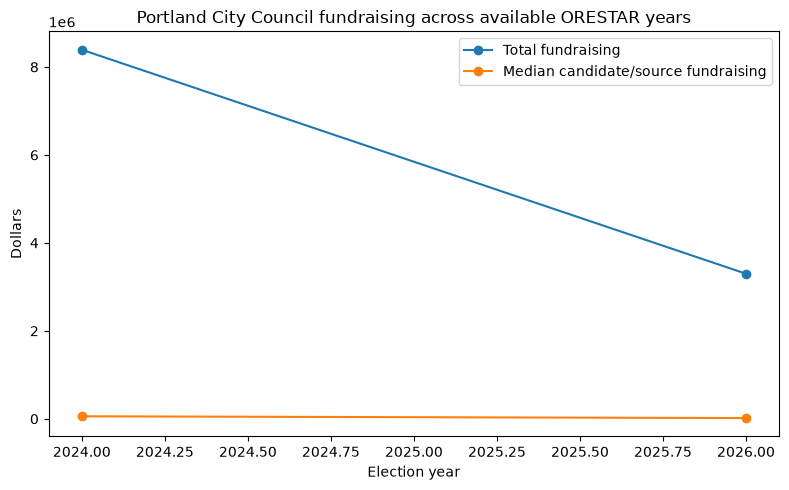

In [7]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    year_summary["year"],
    year_summary["total_fundraising"],
    marker="o",
    label="Total fundraising",
)

ax.plot(
    year_summary["year"],
    year_summary["median_candidate_fundraising"],
    marker="o",
    label="Median candidate/source fundraising",
)

ax.set_xlabel("Election year")
ax.set_ylabel("Dollars")
ax.set_title(
    "Portland City Council fundraising across available ORESTAR years"
)
ax.legend()

plt.tight_layout()
plt.show()


## 8. Spending over time

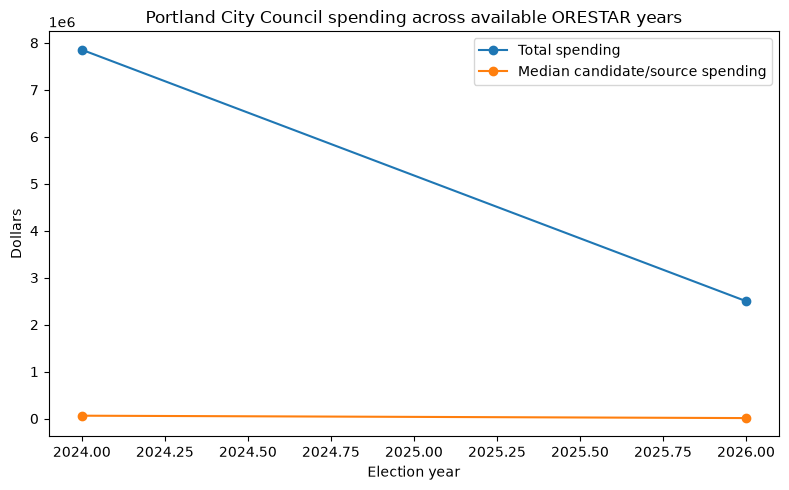

In [8]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    year_summary["year"],
    year_summary["total_spending"],
    marker="o",
    label="Total spending",
)

ax.plot(
    year_summary["year"],
    year_summary["median_candidate_spending"],
    marker="o",
    label="Median candidate/source spending",
)

ax.set_xlabel("Election year")
ax.set_ylabel("Dollars")
ax.set_title(
    "Portland City Council spending across available ORESTAR years"
)
ax.legend()

plt.tight_layout()
plt.show()


## 9. Fundraising vs. spending by candidate/source

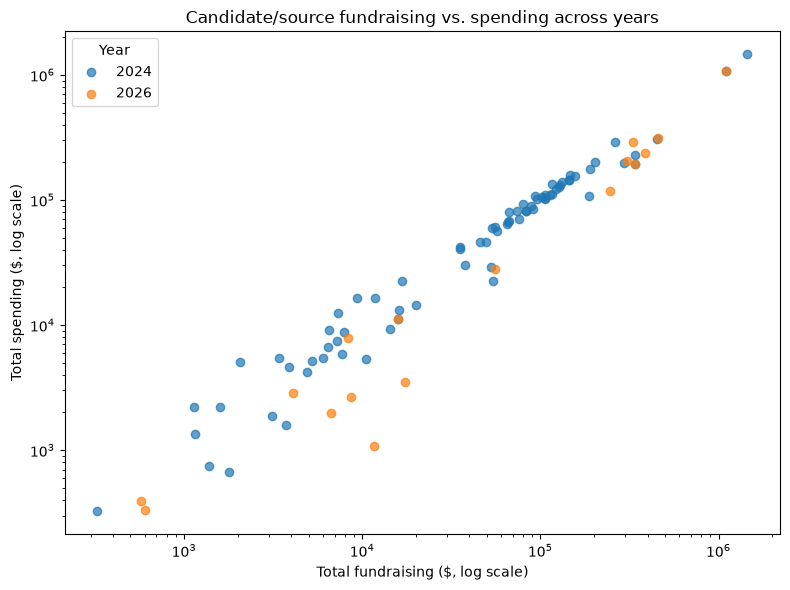

In [9]:
plot_data = candidate_year_finance.dropna(
    subset=[
        "total_fundraising",
        "total_spending",
    ]
).copy()

fig, ax = plt.subplots(
    figsize=(8, 6)
)

for year in sorted(
    plot_data["year"].unique()
):
    sub = plot_data.loc[
        plot_data["year"].eq(year)
    ]

    ax.scatter(
        sub["total_fundraising"],
        sub["total_spending"],
        alpha=0.7,
        label=str(year),
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total fundraising ($, log scale)")
ax.set_ylabel("Total spending ($, log scale)")
ax.set_title(
    "Candidate/source fundraising vs. spending across years"
)
ax.legend(title="Year")

plt.tight_layout()
plt.show()


## 10. Export historical tables

In [10]:
candidate_path = (
    OUTPUT_DIR
    / "candidate_year_finance.csv"
)

year_path = (
    OUTPUT_DIR
    / "year_finance_summary.csv"
)

fundraising_stats_path = (
    OUTPUT_DIR
    / "fundraising_transaction_descriptives_by_year.csv"
)

spending_stats_path = (
    OUTPUT_DIR
    / "spending_transaction_descriptives_by_year.csv"
)

candidate_year_finance.to_csv(
    candidate_path,
    index=False,
)

year_summary.to_csv(
    year_path,
    index=False,
)

fundraising_transaction_stats.to_csv(
    fundraising_stats_path,
)

spending_transaction_stats.to_csv(
    spending_stats_path,
)

print("SAVED", candidate_path)
print("SAVED", year_path)
print("SAVED", fundraising_stats_path)
print("SAVED", spending_stats_path)


SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/finance_history/city_council/candidate_year_finance.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/finance_history/city_council/year_finance_summary.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/finance_history/city_council/fundraising_transaction_descriptives_by_year.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/finance_history/city_council/spending_transaction_descriptives_by_year.csv
